In [ ]:
# Task 1: EDA on Retail Sales Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

In [ ]:
import zipfile
import os

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/retail_data")

print("Dataset extracted successfully!")
print(os.listdir("/content/retail_data"))

Dataset extracted successfully!
['retail_sales_dataset.csv']


In [ ]:
import pandas as pd
import os

csv_file = "/content/retail_data/retail_sales_dataset.csv"

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# Display basic information about the dataset

print("Dataset Information:")
print("=" * 50)

df.info()

print("\n\nMissing Values:")
print("=" * 50)
print(df.isnull().sum())

print("\n\nDuplicate Rows:")
print("=" * 50)
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Duplicate Rows:
0


In [ ]:
# Descriptive statistics for numerical columns

print("Descriptive Statistics")
print("=" * 50)

df.describe()

Descriptive Statistics


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Total Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


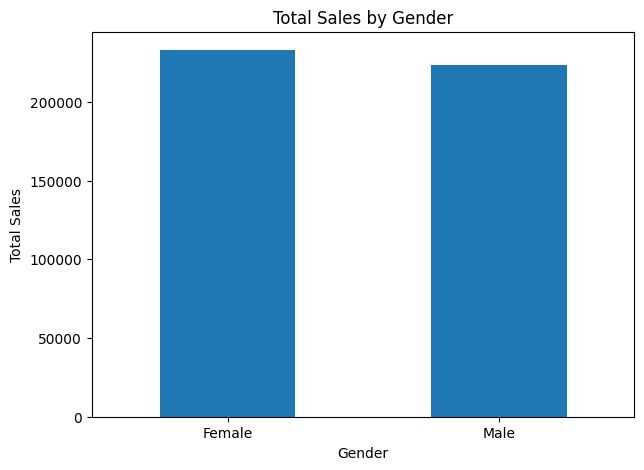

In [ ]:
# Gender-wise sales analysis

gender_sales = df.groupby("Gender")["Total Amount"].sum()

print("Total Sales by Gender:")
print(gender_sales)

plt.figure(figsize=(7, 5))
gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

### Observation

Female customers generated slightly higher total sales than male
customers. This indicates that female customers contributed a somewhat
larger share of the overall revenue in the dataset.

In [ ]:
import matplotlib.pyplot as plt

Customer Distribution by Age Group:
Age Group
Below 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
Above 65      0
Name: count, dtype: int64


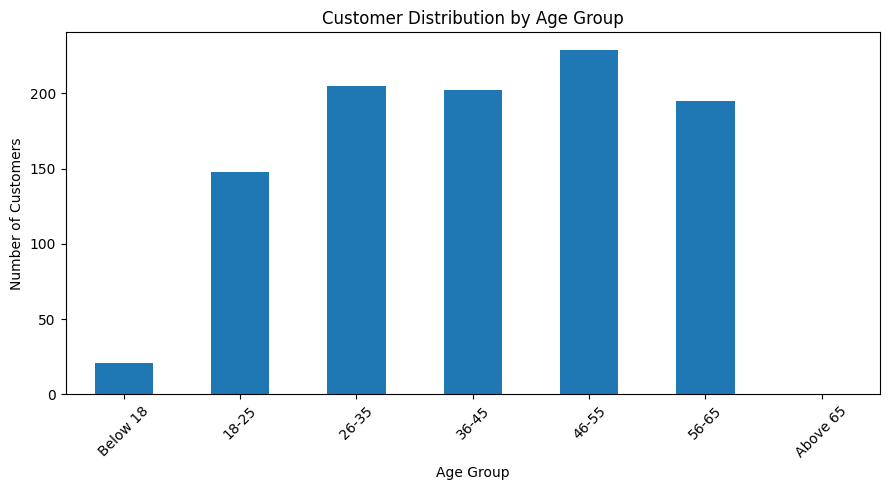

In [ ]:
# Create age groups

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Below 18', '18-25', '26-35', '36-45', '46-55', '56-65', 'Above 65']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count customers in each age group
age_group_counts = df['Age Group'].value_counts().sort_index()

print("Customer Distribution by Age Group:")
print(age_group_counts)

# Plot
plt.figure(figsize=(9, 5))
age_group_counts.plot(kind='bar')

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The age-group analysis shows the distribution of customers across
different age categories. The most represented age group can be
considered an important customer segment for targeted marketing,
while less-represented age groups may require separate promotional
strategies.

Monthly Sales:
Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


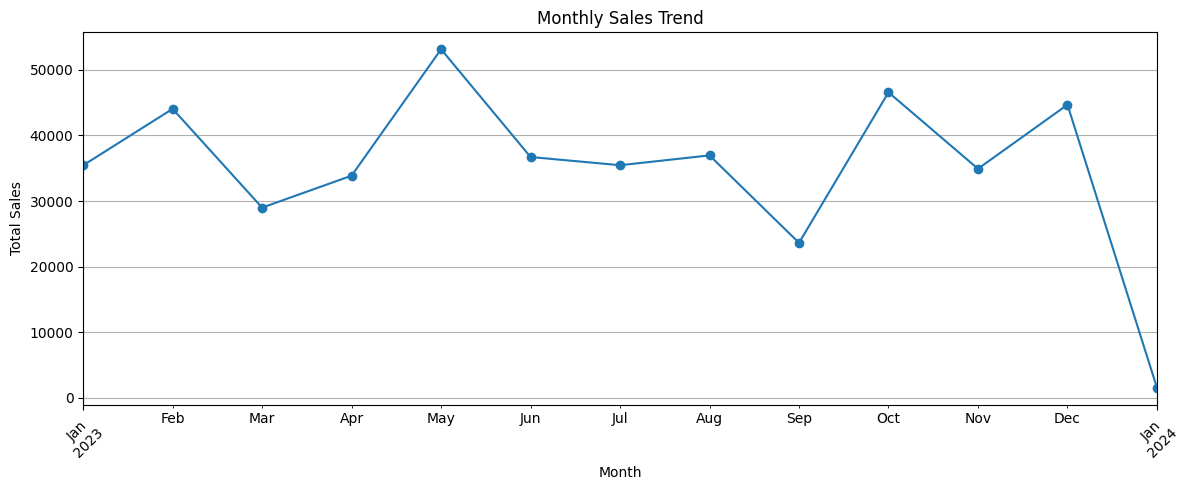

In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly sales
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

print("Monthly Sales:")
print(monthly_sales)

# Plot monthly sales trend
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The age-group analysis shows the distribution of customers across
different age categories. The most represented age group can be
considered an important customer segment for targeted marketing,
while less-represented age groups may require separate promotional
strategies.

Product Category Performance:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


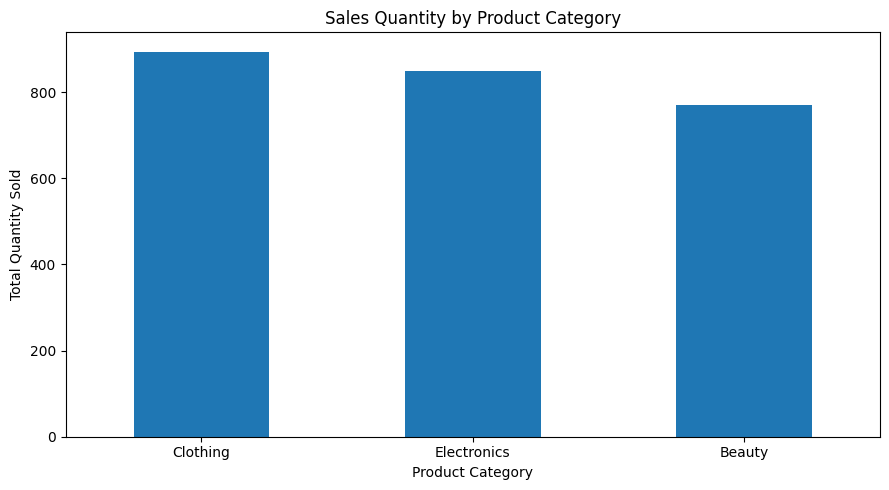

In [ ]:
# Product Category Performance

category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Product Category Performance:")
print(category_quantity)

# Plot
plt.figure(figsize=(9, 5))
category_quantity.plot(kind='bar')

plt.title("Sales Quantity by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Clothing has the highest sales quantity among the three product
categories, followed by Electronics. Beauty has the lowest quantity
sold. This indicates that Clothing is currently the strongest category
in terms of sales volume, while Beauty may need additional promotional
strategies to improve its sales performance.

Top 10 Best-Selling Product Categories:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


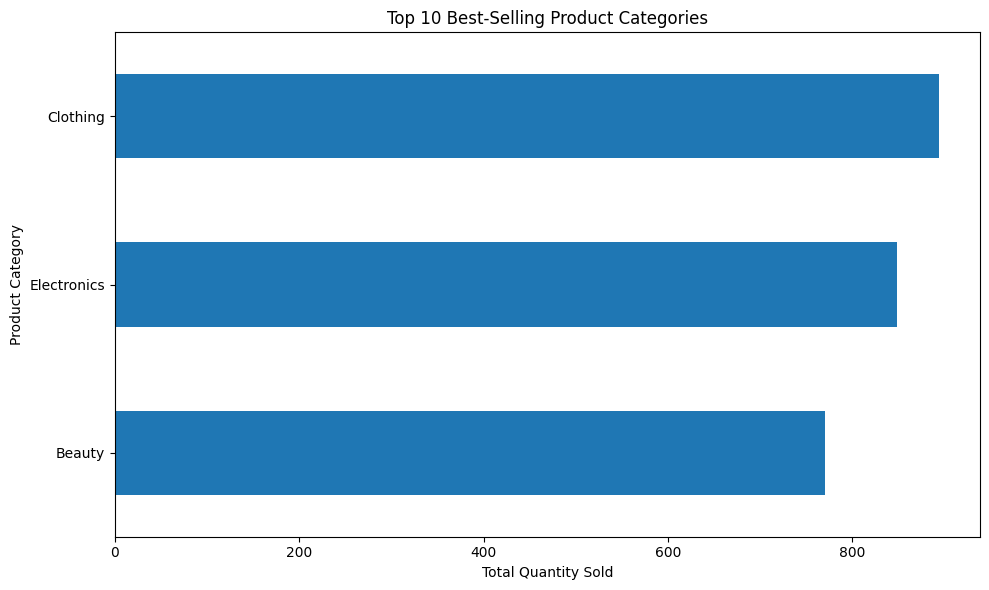

In [ ]:
# Top 10 best-selling products by quantity

top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Best-Selling Product Categories:")
print(top_products)

# Plot
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Best-Selling Product Categories")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Revenue by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


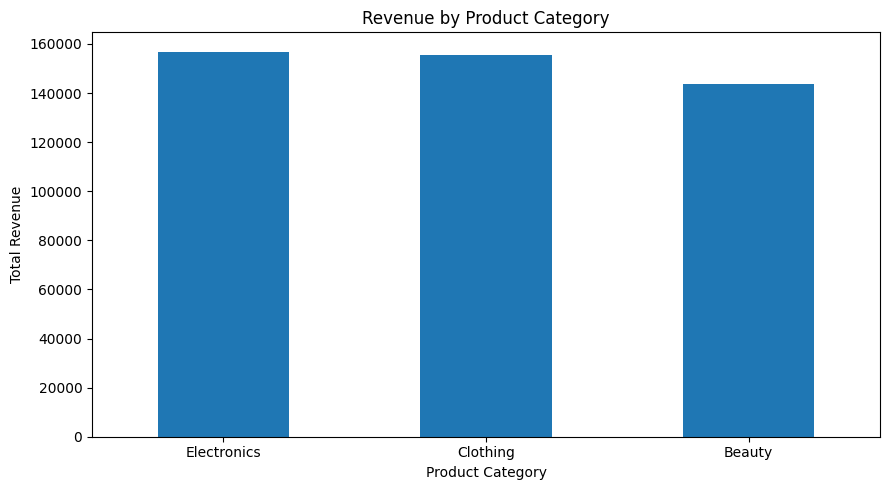

In [ ]:
# Revenue by Product Category

category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Product Category:")
print(category_revenue)

# Plot
plt.figure(figsize=(9, 5))
category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation Matrix:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


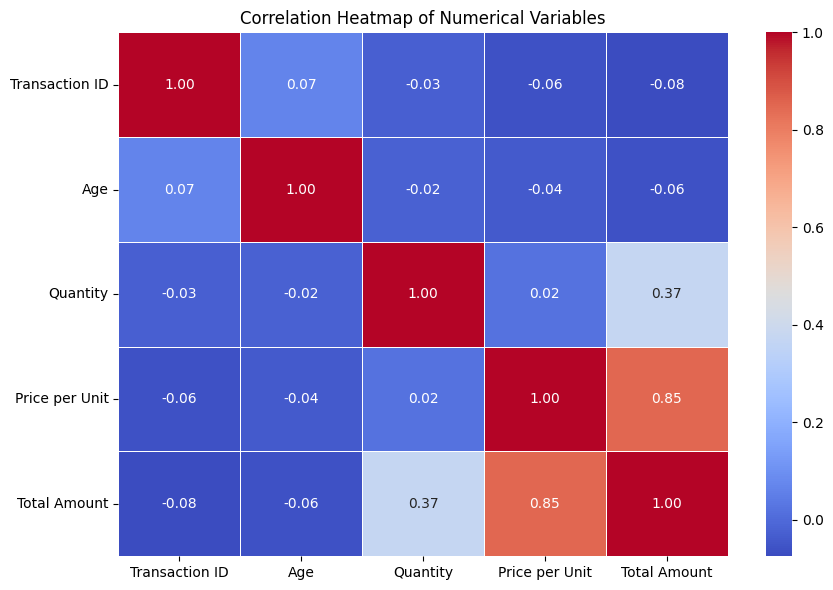

In [ ]:
# Correlation Matrix

numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

Average Spending by Age Group:
Age Group
Below 18    534.047619
18-25       495.506757
26-35       480.390244
36-45       454.801980
46-55       439.694323
56-65       412.358974
Name: Total Amount, dtype: float64


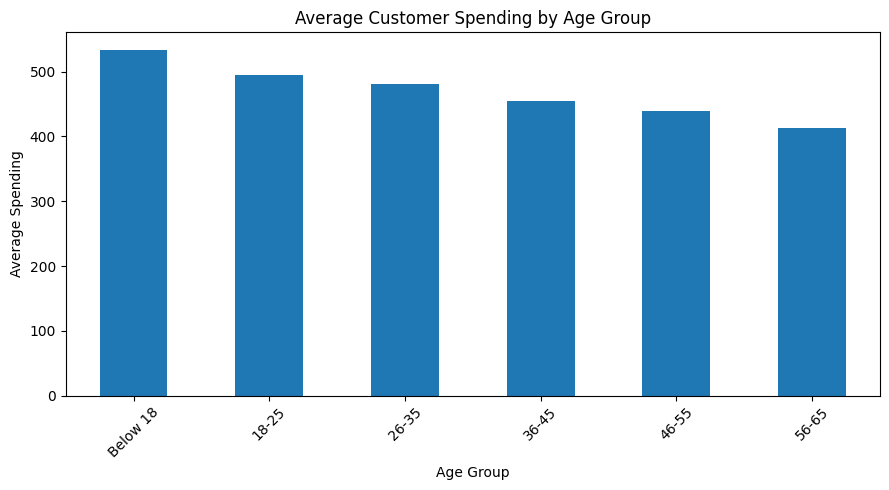

In [ ]:
# Average spending by age group

age_spending = (
    df.groupby('Age Group', observed=True)['Total Amount']
    .mean()
    .sort_values(ascending=False)
)

print("Average Spending by Age Group:")
print(age_spending)

# Plot
plt.figure(figsize=(9, 5))
age_spending.plot(kind='bar')

plt.title("Average Customer Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Key Business Insights

highest_gender = gender_sales.idxmax()
highest_gender_sales = gender_sales.max()

highest_age_group = age_spending.idxmax()
highest_age_spending = age_spending.max()

highest_category = category_revenue.idxmax()
highest_category_revenue = category_revenue.max()

highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print(f"1. {highest_gender} customers generated the highest total sales "
      f"of {highest_gender_sales:,.2f}.")

print(f"2. The {highest_age_group} age group has the highest average "
      f"customer spending of {highest_age_spending:,.2f}.")

print(f"3. {highest_category} generated the highest revenue of "
      f"{highest_category_revenue:,.2f}.")

print(f"4. The highest monthly sales occurred in {highest_month}, "
      f"with sales of {highest_month_sales:,.2f}.")

KEY BUSINESS INSIGHTS
1. Female customers generated the highest total sales of 232,840.00.
2. The Below 18 age group has the highest average customer spending of 534.05.
3. Electronics generated the highest revenue of 156,905.00.
4. The highest monthly sales occurred in 2023-05, with sales of 53,150.00.


## Conclusion

The exploratory data analysis provided useful insights into customer
behaviour, sales trends, and product-category performance.

### Business Recommendations

1. **Focus on high-performing customer segments:**  
   Marketing campaigns should target the customer groups that generate
   higher sales and average spending.

2. **Strengthen high-revenue product categories:**  
   The highest-revenue categories should receive greater promotional
   attention, inventory planning, and product visibility.

3. **Use sales trends for planning:**  
   Monthly and quarterly sales patterns can be used to plan inventory,
   staffing, and promotional campaigns during high-demand periods.

4. **Improve customer targeting:**  
   Age-group and gender analysis can help create more personalized
   marketing campaigns and offers.

5. **Monitor sales performance regularly:**  
   Repeating this analysis periodically can help identify changes in
   customer behaviour and revenue patterns.